In [1]:
import yfinance as yf
import pandas as pd

stocks = ['INFY.NS', 'TCS.NS', 'WIPRO.NS']

data = yf.download(stocks, start='2021-01-01', end='2024-12-31')

print(data.head())

[*********************100%***********************]  3 of 3 completed

Price             Close                                  High               \
Ticker          INFY.NS       TCS.NS    WIPRO.NS      INFY.NS       TCS.NS   
2021-01-01  1109.599609  2534.896973  178.880463  1114.045270  2545.068590   
2021-01-04  1134.072754  2631.159424  182.706055  1135.613315  2640.941533   
2021-01-05  1138.958496  2677.515869  187.269089  1143.536119  2695.911347   
2021-01-06  1128.658813  2641.590820  187.315186  1146.177212  2695.262336   
2021-01-07  1111.096313  2625.403076  187.476517  1142.347685  2666.998547   

Price                           Low                                  Open  \
Ticker        WIPRO.NS      INFY.NS       TCS.NS    WIPRO.NS      INFY.NS   
2021-01-01  180.101880  1105.506206  2492.262745  177.474669  1107.354857   
2021-01-04  183.420479  1110.216093  2545.890968  178.742197  1117.126586   
2021-01-05  188.882285  1122.452490  2631.289201  181.369403  1128.570673   
2021-01-06  192.385232  1116.290376  2629.211703  185.886351  1144.4

In [2]:
returns = data['Close'].pct_change()

returns.head()

Ticker,INFY.NS,TCS.NS,WIPRO.NS
2021-01-01,NaN,NaN,NaN
2021-01-04,0.022056,0.037975,0.021386
2021-01-05,0.004308,0.017618,0.024975
2021-01-06,-0.009043,-0.013417,0.000246
2021-01-07,-0.015561,-0.006128,0.000861


In [3]:
correlation = returns.corr()

print(correlation)

Ticker     INFY.NS    TCS.NS  WIPRO.NS
Ticker                                
INFY.NS   1.000000  0.691807  0.623656
TCS.NS    0.691807  1.000000  0.603856
WIPRO.NS  0.623656  0.603856  1.000000


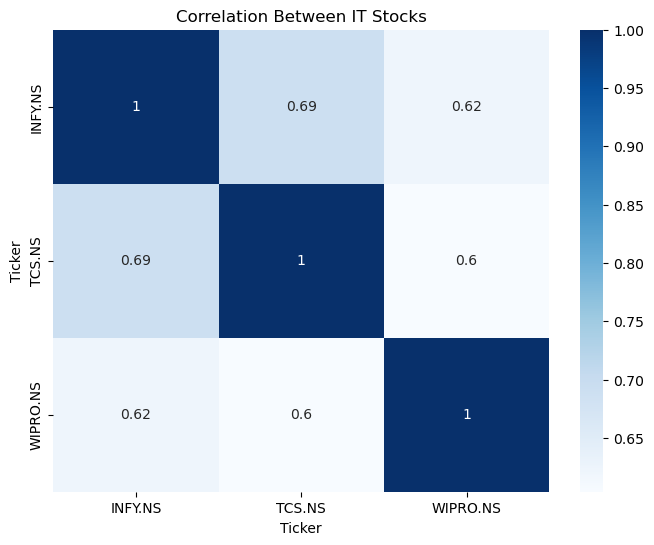

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.title('Correlation Between IT Stocks')
plt.show()

In [5]:
volatility = returns.std() * (252 ** 0.5)

print(volatility)

Ticker
INFY.NS     0.238238
TCS.NS      0.209709
WIPRO.NS    0.260227
dtype: float64


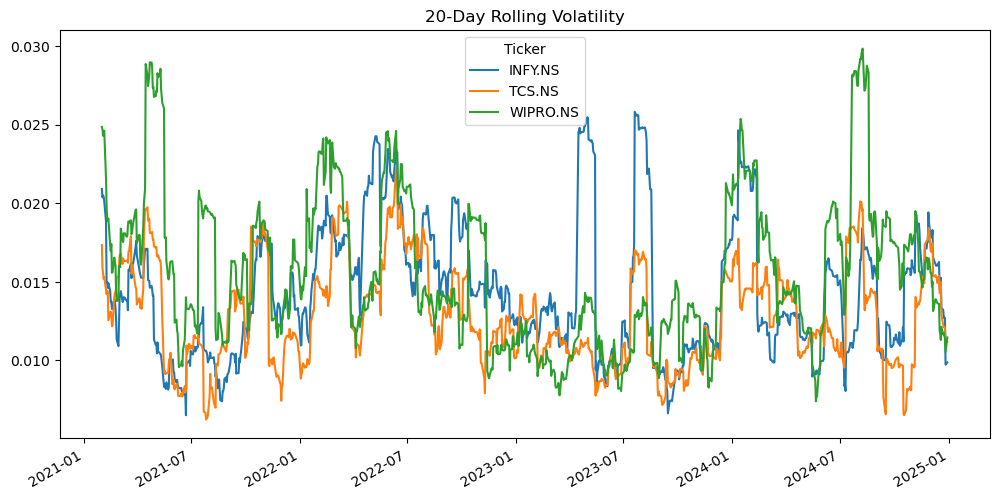

In [6]:
rolling_vol = returns.rolling(20).std()

rolling_vol.plot(figsize=(12,6))
plt.title("20-Day Rolling Volatility")
plt.show()

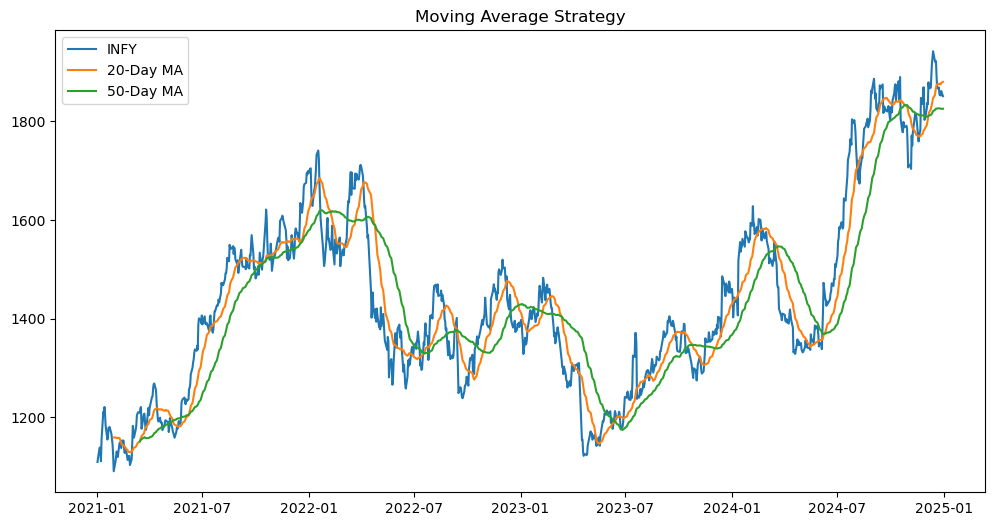

In [7]:
infy = data['Close']['INFY.NS']

ma20 = infy.rolling(20).mean()
ma50 = infy.rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(infy, label='INFY')
plt.plot(ma20, label='20-Day MA')
plt.plot(ma50, label='50-Day MA')

plt.legend()
plt.title('Moving Average Strategy')
plt.show()

In [8]:
signals = pd.DataFrame(index=infy.index)

signals['price'] = infy
signals['ma20'] = ma20
signals['ma50'] = ma50

signals['signal'] = 0

signals.loc[signals.index[20:], 'signal'] = (
    signals.loc[signals.index[20:], 'ma20'] >
    signals.loc[signals.index[20:], 'ma50']
).astype(int)

signals['position'] = signals['signal'].diff()

print(signals.head())

                  price  ma20  ma50  signal  position
2021-01-01  1109.599609   NaN   NaN       0       NaN
2021-01-04  1134.072754   NaN   NaN       0       0.0
2021-01-05  1138.958496   NaN   NaN       0       0.0
2021-01-06  1128.658813   NaN   NaN       0       0.0
2021-01-07  1111.096313   NaN   NaN       0       0.0


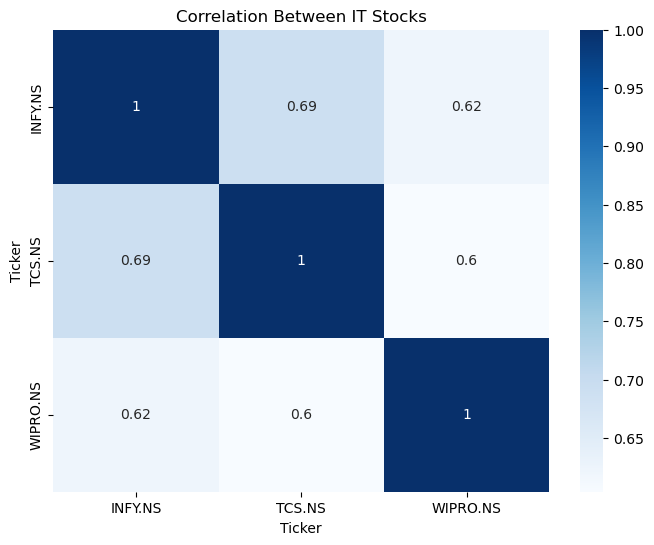

In [9]:
import os

os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='Blues')

plt.title('Correlation Between IT Stocks')

plt.savefig("charts/correlation_heatmap.png")

plt.show()

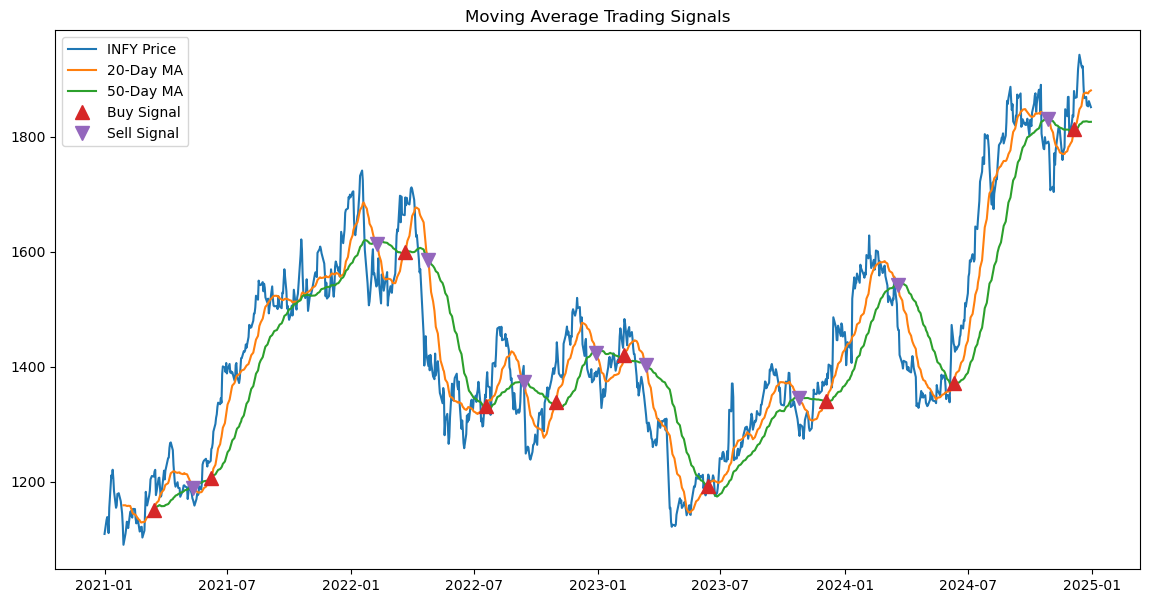

In [10]:
plt.figure(figsize=(14,7))

plt.plot(signals['price'], label='INFY Price')
plt.plot(signals['ma20'], label='20-Day MA')
plt.plot(signals['ma50'], label='50-Day MA')

plt.plot(
    signals[signals['position'] == 1].index,
    signals['ma20'][signals['position'] == 1],
    '^',
    markersize=10,
    label='Buy Signal'
)

plt.plot(
    signals[signals['position'] == -1].index,
    signals['ma20'][signals['position'] == -1],
    'v',
    markersize=10,
    label='Sell Signal'
)

plt.title('Moving Average Trading Signals')
plt.legend()
plt.show()

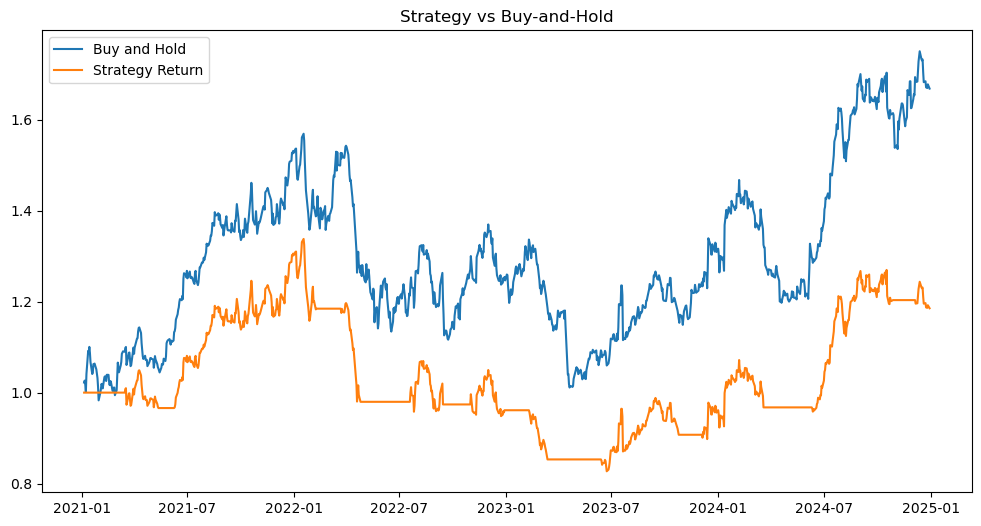

In [11]:
signals['daily_return'] = signals['price'].pct_change()

signals['strategy_return'] = (
    signals['daily_return'] * signals['signal'].shift(1)
)

cumulative_market = (1 + signals['daily_return']).cumprod()

cumulative_strategy = (1 + signals['strategy_return']).cumprod()

plt.figure(figsize=(12,6))

plt.plot(cumulative_market, label='Buy and Hold')
plt.plot(cumulative_strategy, label='Strategy Return')

plt.title('Strategy vs Buy-and-Hold')
plt.legend()
plt.show()

In [12]:
strategy_returns = signals['strategy_return'].dropna()

annual_return = strategy_returns.mean() * 252
annual_volatility = strategy_returns.std() * (252 ** 0.5)

sharpe_ratio = annual_return / annual_volatility

print("Annual Return:", annual_return)
print("Annual Volatility:", annual_volatility)
print("Sharpe Ratio:", sharpe_ratio)

Annual Return: 0.05995961038853734
Annual Volatility: 0.1812110518107012
Sharpe Ratio: 0.3308827457785138
